<a href="https://colab.research.google.com/github/ydg1021/test/blob/main/%EB%93%9C%EB%A1%A0%EC%A2%85%EB%A5%98%EB%B6%84%EB%A5%98_%EA%B0%80%EC%9D%B4%EB%93%9C%EC%BD%94%EB%93%9C_ipynb%EC%9D%98_%EC%82%AC%EB%B3%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 드론 종류 분류 프로젝트 (Ground-to-Sky 버전)
## Intel OpenVINO x 금오공과대학교 VisionAI

---

### 프로젝트 개요

| 항목 | 내용 |
|------|------|
| **프로젝트명** | 드론 종류 자동 분류 시스템 (Counter-Drone Intelligence) |
| **핵심 목적** | 지상 탐지 카메라 이미지로 드론 기종 식별 |
| **분류 클래스** | VTOL / QUAD / HEXA - 3종 |
| **핵심 기술** | Ground-to-Sky 필터 -> MobileNetV2 전이학습 -> OpenVINO IR 변환 |

### 왜 Ground-to-Sky 필터링이 필요한가?

데이터셋에는 두 종류의 이미지가 혼재합니다:
- **Ground-to-Sky**: 지상 탐지 카메라가 하늘의 드론을 촬영 → 드론 형태가 사진에 보임
- **Sky-to-Ground**: 드론이 지표면을 내려다보며 촬영 → 드론이 사진에 없음

'이 사진에 찍힌 드론은 어떤 종류인가?'라는 실용적 시나리오에 맞게
Ground-to-Sky 이미지만 선별하여 사용합니다.


## STEP 01 · 환경 설정

In [ ]:
# -- 1-1. 패키지 설치
#!pip install torch torchvision tqdm scikit-learn matplotlib seaborn  -q
!pip install openvino onnxscript onnx koreanize-matplotlib -q
print("패키지 설치 완료")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 MB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 73.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 55.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 9.4 MB/s eta 0:00:00
패키지 설치 완료


In [ ]:
# -- 1-2. 라이브러리 임포트
import os, shutil, random, time, warnings
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import models, transforms
from torchvision.datasets import ImageFolder
from tqdm.auto import tqdm

from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, confusion_matrix)
import openvino as ov

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"사용 장치 : {DEVICE}")
print(f"PyTorch  : {torch.__version__}")
print(f"OpenVINO : {ov.__version__}")

사용 장치 : cuda
PyTorch  : 2.11.0+cu128
OpenVINO : 2026.2.1-21919-ede283a88e3-releases/2026/2


## STEP 02 · 데이터셋 구축

In [ ]:
# -- 2-1. Google Drive 마운트
from google.colab import drive
drive.mount('/content/drive')

import os
DRIVE_ROOT = '/content/drive/MyDrive/2026_금오공대_비전AI엔지니어양성과정/Project'
os.chdir(DRIVE_ROOT)
print(f"작업 디렉토리: {os.getcwd()}")

Mounted at /content/drive
작업 디렉토리: /content/drive/MyDrive/2026_금오공대_비전AI엔지니어양성과정/Project


In [ ]:
# -- 2-2. 데이터셋 압축 해제 (Drive -> /content/)
import zipfile, subprocess

DRIVE_ROOT_PATH = Path(DRIVE_ROOT)
BASE = '/content'

def extract_zip(src, dst):
    if Path(dst).exists():
        print(f"  이미 존재: {Path(dst).name}"); return
    print(f"  압축 해제: {Path(src).name}")
    Path(dst).mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(src) as z:
        z.extractall(dst)
    print(f"  완료: {Path(dst).name}")

def extract_7z(first_part, extract_to, result_dir):
    """
    extract_to : 7z를 풀 부모 폴더
    result_dir : 생성될 실제 폴더 (존재 여부 체크용)
    HEXA 7z 내부에 L1_HEXA_MC/ 가 포함되어 있으므로
    extract_to = /content 로 설정해야 /content/L1_HEXA_MC/cloud/... 구조가 됨
    """
    if Path(result_dir).exists():
        print(f"  이미 존재: {Path(result_dir).name}"); return
    print("  HEXA 7z 압축 해제 중...")
    subprocess.run(['7z', 'x', str(first_part), f'-o{extract_to}', '-y'],
                   check=True, capture_output=True)
    print(f"  완료: {Path(result_dir).name}")

print("데이터셋 준비 중...")
extract_zip(DRIVE_ROOT_PATH / 'L1_LC_VTOL.zip', f'{BASE}/L1_LC_VTOL')
extract_zip(DRIVE_ROOT_PATH / 'L3_QUAD_MC.zip', f'{BASE}/L3_QUAD_MC')
extract_7z(
    first_part = DRIVE_ROOT_PATH / 'L1_HEXA_MC.7z.001',
    extract_to = BASE,                    # ← /content 에 풀기 (7z 내부에 L1_HEXA_MC/ 포함)
    result_dir = f'{BASE}/L1_HEXA_MC',   # ← 완료 확인용
)
print("모든 데이터셋 준비 완료")

데이터셋 준비 중...
  압축 해제: L1_LC_VTOL.zip
  완료: L1_LC_VTOL
  압축 해제: L3_QUAD_MC.zip
  완료: L3_QUAD_MC
  HEXA 7z 압축 해제 중...
  완료: L1_HEXA_MC
모든 데이터셋 준비 완료


In [ ]:
# -- 2-3. 데이터셋 구조 파악
DATASETS = {
    'VTOL': f'{BASE}/L1_LC_VTOL',
    'QUAD': f'{BASE}/L3_QUAD_MC',
    'HEXA': f'{BASE}/L1_HEXA_MC',
}
USE_ENVS    = ['country', 'sunny', 'urban', 'snow', 'low-light']
EXCLUDE_DIST = ['장거리', '중거리', '미분류']  # 거리 불명확 이미지 모두 제외

print(f"{'클래스':<8} {'환경':<14} {'하위폴더':<12} {'이미지수':>8}")
print("=" * 50)
raw_paths = {}
for cls, root in DATASETS.items():
    raw_paths[cls] = []
    for env in USE_ENVS:
        env_p = Path(root) / env
        if not env_p.exists(): continue
        subs = [s for s in env_p.iterdir() if s.is_dir()]
        if subs:
            for sub in sorted(subs):
                if sub.name in EXCLUDE_DIST: continue  # 장거리 제외
                imgs = list(sub.glob('*.jpg')) + list(sub.glob('*.jpeg'))
                raw_paths[cls].extend(imgs)
                print(f"{cls:<8} {env:<14} {sub.name:<12} {len(imgs):>8}")
        else:
            imgs = list(env_p.glob('*.jpg')) + list(env_p.glob('*.jpeg'))
            raw_paths[cls].extend(imgs)
            print(f"{cls:<8} {env:<14} {'(flat)':<12} {len(imgs):>8}")
print("=" * 50)
for cls, ps in raw_paths.items():
    print(f"  {cls} 합계: {len(ps):,}장")
print(f"  전체 합계: {sum(len(v) for v in raw_paths.values()):,}장")

클래스      환경             하위폴더             이미지수
VTOL     country        단거리               325
VTOL     sunny          단거리               166
VTOL     urban          단거리               325
VTOL     snow           단거리               574
VTOL     low-light      단거리               525
QUAD     country        단거리               326
QUAD     sunny          단거리               161
QUAD     urban          단거리               329
QUAD     snow           단거리               630
QUAD     low-light      단거리               416
HEXA     country        단거리               320
HEXA     sunny          단거리               320
HEXA     urban          단거리               642
HEXA     snow           단거리               442
HEXA     low-light      단거리               585
  VTOL 합계: 1,915장
  QUAD 합계: 1,862장
  HEXA 합계: 2,309장
  전체 합계: 6,086장


In [ ]:
# -- 2-4. Ground-to-Sky 필터링
#
# [원리] 이미지 상단 40%를 분석하여 하늘 색상 비율이 threshold 이상이면
# Ground-to-Sky (지상 카메라 -> 하늘)로 판단합니다.
#
# 하늘 판별 기준 (OR):
#   1. 파란 하늘  : 파란 채널 > 빨강, 밝기 > 0.2
#   2. 흐린 하늘  : 밝기 > 0.65, 채널간 편차 < 0.20
#   3. 고밝기 영역: 밝기 > 0.78 (눈/구름 배경)

def is_ground_to_sky(img_path, threshold=0.35):
    try:
        img = Image.open(img_path).convert('RGB').resize((64, 64))
        arr = np.array(img, dtype=np.float32) / 255.0
        top = arr[:26, :, :]   # 상단 40%
        bot = arr[45:, :, :]   # 하단 30%

        r, g, b = top[:,:,0], top[:,:,1], top[:,:,2]
        bright = (r + g + b) / 3.0
        blue_sky   = (b > r + 0.04) & (b > g - 0.01) & (bright > 0.20)
        white_sky  = (bright > 0.65) & (np.abs(r - b) < 0.20) & (np.abs(r - g) < 0.20)
        bright_uni = bright > 0.78
        sky_ratio = float((blue_sky | white_sky | bright_uni).mean())

        # 하단이 하늘처럼 밝고 균일하면 항공샷 → 제외
        r2, g2, b2 = bot[:,:,0], bot[:,:,1], bot[:,:,2]
        bright2 = (r2 + g2 + b2) / 3.0
        bot_sky_ratio = float((bright2 > 0.65).mean())

        return sky_ratio > threshold and bot_sky_ratio < 0.40
    except Exception:
        return False

print("Ground-to-Sky 필터링 중 (멀티스레드)...")
filtered_paths = {}
for cls, paths in raw_paths.items():
    with ThreadPoolExecutor(max_workers=8) as ex:
        flags = list(tqdm(ex.map(is_ground_to_sky, paths),
                          total=len(paths), desc=f'  {cls}'))
    gts = [p for p, f in zip(paths, flags) if f]
    filtered_paths[cls] = gts
    ratio = len(gts) / len(paths) * 100
    print(f"  {cls}: {len(paths):,}장 -> {len(gts):,}장 ({ratio:.1f}% Ground-to-Sky)")

print(f"필터링 후 합계: {sum(len(v) for v in filtered_paths.values()):,}장")

Ground-to-Sky 필터링 중 (멀티스레드)...


  VTOL:   0%|          | 0/1915 [00:00<?, ?it/s]

  VTOL: 1,915장 -> 1,128장 (58.9% Ground-to-Sky)


  QUAD:   0%|          | 0/1862 [00:00<?, ?it/s]

  QUAD: 1,862장 -> 1,205장 (64.7% Ground-to-Sky)


  HEXA:   0%|          | 0/2309 [00:00<?, ?it/s]

  HEXA: 2,309장 -> 1,675장 (72.5% Ground-to-Sky)
필터링 후 합계: 4,008장


In [ ]:
# -- 2-5. 30% 균형 샘플링 + Train/Val/Test 분할
from sklearn.model_selection import train_test_split

SAMPLE_RATIO = 0.30
MERGED_DIR   = f'{BASE}/drone_clf_gts'
SPLITS       = ['train', 'val', 'test']

min_cnt    = min(len(v) for v in filtered_paths.values())
sample_cnt = int(min_cnt * SAMPLE_RATIO)
print(f"클래스별 최솟값: {min_cnt:,}장  ->  30% 샘플: {sample_cnt:,}장/클래스")

for split in SPLITS:
    for cls in DATASETS:
        Path(f'{MERGED_DIR}/{split}/{cls}').mkdir(parents=True, exist_ok=True)

counts = {}
for cls, paths in filtered_paths.items():
    random.seed(SEED)
    sel = random.sample(paths, sample_cnt)
    tr, tmp  = train_test_split(sel, test_size=0.30, random_state=SEED)
    val, te  = train_test_split(tmp, test_size=0.50, random_state=SEED)
    for split, ps in [('train', tr), ('val', val), ('test', te)]:
        dst_dir = Path(f'{MERGED_DIR}/{split}/{cls}')
        for p in ps:
            dst = dst_dir / p.name
            if not dst.exists(): shutil.copy2(p, dst)
    counts[cls] = {'train': len(tr), 'val': len(val), 'test': len(te)}

print(f"\n{'클래스':<8} {'Train':>8} {'Val':>6} {'Test':>6} {'합계':>8}")
print("-" * 36)
for cls, c in counts.items():
    tot = sum(c.values())
    print(f"{cls:<8} {c['train']:>8} {c['val']:>6} {c['test']:>6} {tot:>8}")
print("\n  -> Train:Val:Test = 70:15:15  |  Ground-to-Sky 이미지만 사용")

클래스별 최솟값: 1,128장  ->  30% 샘플: 338장/클래스

클래스         Train    Val   Test       합계
------------------------------------
VTOL          236     51     51      338
QUAD          236     51     51      338
HEXA          236     51     51      338

  -> Train:Val:Test = 70:15:15  |  Ground-to-Sky 이미지만 사용


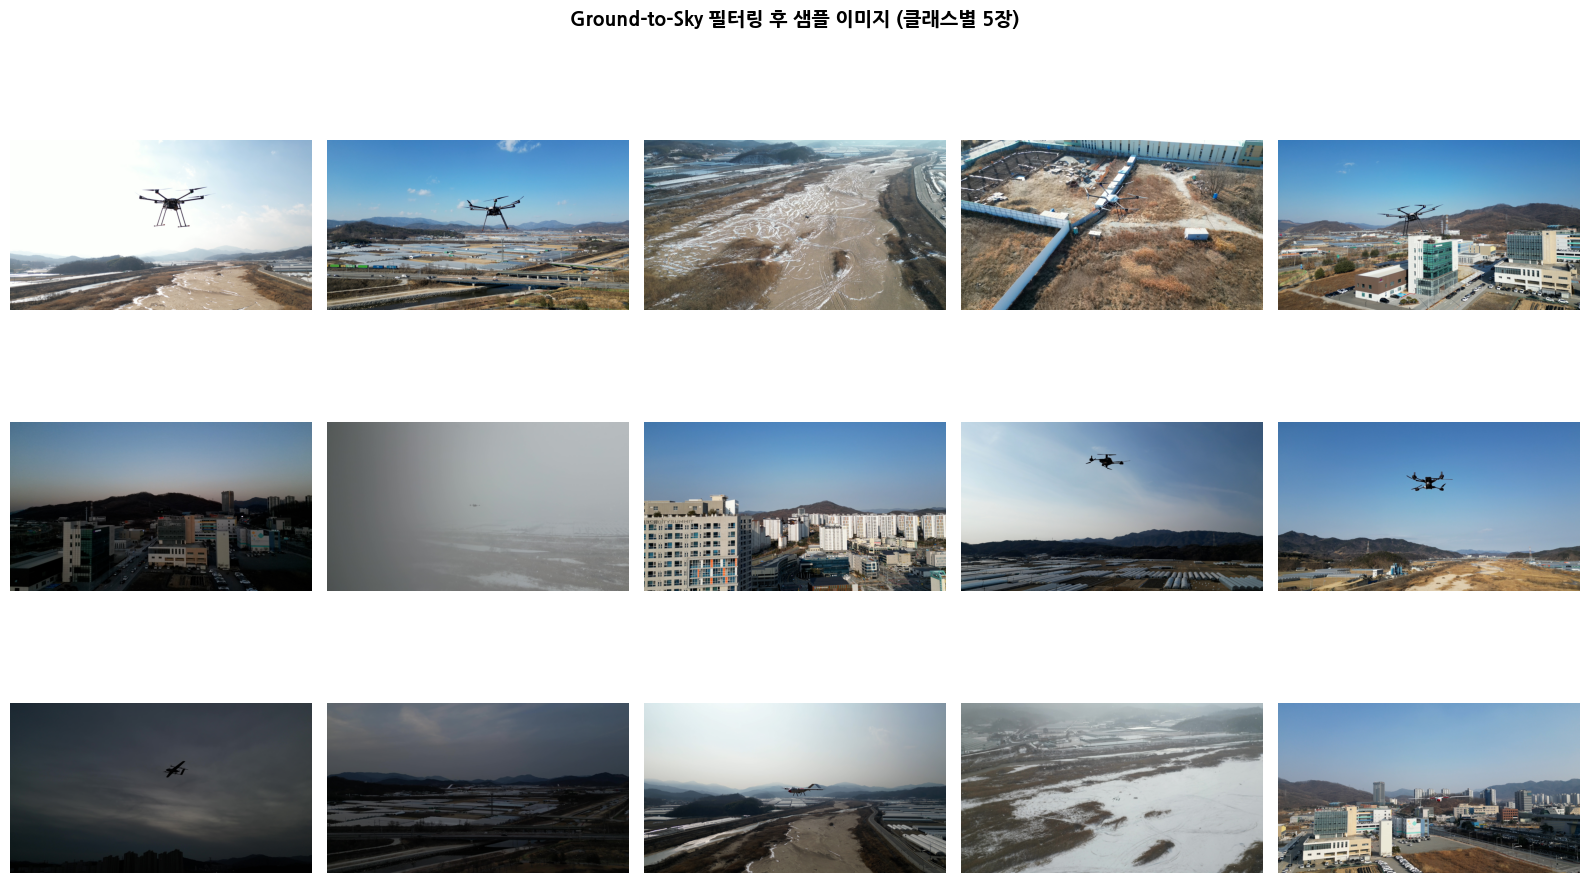

저장: /content/sample_gts.png


In [ ]:
# -- 2-6. 샘플 이미지 시각화 (Ground-to-Sky 확인)
fig, axes = plt.subplots(3, 5, figsize=(16, 10))
fig.suptitle('Ground-to-Sky 필터링 후 샘플 이미지 (클래스별 5장)', fontsize=14, fontweight='bold')

for row, cls in enumerate(['HEXA', 'QUAD', 'VTOL']):
    cls_dir = Path(f'{MERGED_DIR}/train/{cls}')
    imgs = list(cls_dir.glob('*.jpg')) + list(cls_dir.glob('*.jpeg'))
    random.shuffle(imgs)
    for col in range(5):
        ax = axes[row][col]
        ax.imshow(Image.open(imgs[col]).convert('RGB'))
        if col == 0: ax.set_ylabel(cls, fontsize=12, fontweight='bold')
        ax.axis('off')

plt.tight_layout()
plt.savefig('/content/sample_gts.png', dpi=100, bbox_inches='tight')
# plt.savefig(f'{DRIVE_ROOT}/sample_gts.png', dpi=100, bbox_inches='tight')
plt.show()
print("저장: /content/sample_gts.png")

In [ ]:
# -- 2-7. DataLoader 준비
IMG_SIZE   = 224
BATCH_SIZE = 32
NUM_WORKERS = 2

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.65, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

train_ds = ImageFolder(f'{MERGED_DIR}/train', transform=train_tf)
val_ds   = ImageFolder(f'{MERGED_DIR}/val',   transform=eval_tf)
test_ds  = ImageFolder(f'{MERGED_DIR}/test',  transform=eval_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

CLASS_NAMES = train_ds.classes
print(f"클래스 순서 : {CLASS_NAMES}")
print(f"Train       : {len(train_ds):,}장  ({len(train_loader)} 배치)")
print(f"Val         : {len(val_ds):,}장  ({len(val_loader)} 배치)")
print(f"Test        : {len(test_ds):,}장  ({len(test_loader)} 배치)")

클래스 순서 : ['HEXA', 'QUAD', 'VTOL']
Train       : 1,135장  (36 배치)
Val         : 305장  (10 배치)
Test        : 307장  (10 배치)


## STEP 03 · 모델 학습 및 성능 평가

In [ ]:
# -- 3-1. MobileNetV2 전이학습 모델 설정
NUM_CLASSES   = 3
PHASE1_EPOCHS = 10
PHASE2_EPOCHS = 20
PHASE1_LR     = 1e-3
PHASE2_LR     = 1e-4
PATIENCE      = 5

model = models.mobilenet_v2(weights='IMAGENET1K_V1')
for param in model.features.parameters():
    param.requires_grad = False
model.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(model.last_channel, NUM_CLASSES),
)
model = model.to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"총 파라미터   : {total:,}")
print(f"학습 가능     : {trainable:,}  ({trainable/total*100:.1f}%)")
print(f"동결(frozen)  : {total-trainable:,}  ({(total-trainable)/total*100:.1f}%)")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 125MB/s]


총 파라미터   : 2,227,715
학습 가능     : 3,843  (0.2%)
동결(frozen)  : 2,223,872  (99.8%)


In [ ]:
# -- 3-2. 학습 / 검증 함수
def run_epoch(model, loader, optimizer, criterion, device, train=True):
    model.train() if train else model.eval()
    total_loss, correct, n = 0.0, 0, 0
    ctx  = torch.enable_grad() if train else torch.no_grad()
    desc = 'Train' if train else 'Val  '
    pbar = tqdm(loader, desc=f'  [{desc}]', ncols=90, leave=False)
    with ctx:
        for imgs, labels in pbar:
            imgs, labels = imgs.to(device), labels.to(device)
            if train: optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, labels)
            if train: loss.backward(); optimizer.step()
            preds       = out.argmax(1)
            total_loss += loss.item() * imgs.size(0)
            correct    += (preds == labels).sum().item()
            n          += imgs.size(0)
            pbar.set_postfix({'loss': f'{total_loss/n:.4f}', 'acc': f'{correct/n:.4f}'})
    return total_loss / n, correct / n

def train_phase(model, tr_ld, val_ld, optimizer, criterion,
                epochs, device, name, scheduler=None, patience=5):
    history = {'tr_loss':[], 'val_loss':[], 'tr_acc':[], 'val_acc':[]}
    best_acc, best_wts, no_improve = 0.0, None, 0
    print(f'\n{"="*60}\n  {name}  (최대 {epochs} 에포크 | patience={patience})\n{"="*60}')
    print(f'  {"Epoch":>5} | {"TrLoss":>7} {"ValLoss":>7} | {"TrAcc":>7} {"ValAcc":>7}')
    print(f'  {"-"*50}')
    for ep in range(1, epochs + 1):
        tr_loss,  tr_acc  = run_epoch(model, tr_ld,  optimizer, criterion, device, True)
        val_loss, val_acc = run_epoch(model, val_ld, optimizer, criterion, device, False)
        if scheduler: scheduler.step()
        for k, v in [('tr_loss',tr_loss),('val_loss',val_loss),('tr_acc',tr_acc),('val_acc',val_acc)]:
            history[k].append(v)
        flag = ''
        if val_acc > best_acc:
            best_acc = val_acc
            best_wts = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0; flag = '  *'
        else:
            no_improve += 1
        print(f'  {ep:>5} | {tr_loss:>7.4f} {val_loss:>7.4f} | {tr_acc:>7.4f} {val_acc:>7.4f}{flag}')
        if no_improve >= patience:
            print(f'  -> Early stopping  (best val_acc: {best_acc:.4f})'); break
    model.load_state_dict({k: v.to(device) for k, v in best_wts.items()})
    print(f'  완료  최고 Val Acc: {best_acc:.4f}')
    return history, best_acc

In [ ]:
# -- 3-3. Phase 1: 분류기만 학습 (Frozen Base)
criterion  = nn.CrossEntropyLoss()
optimizer1 = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=PHASE1_LR)

hist1, best1 = train_phase(
    model, train_loader, val_loader, optimizer1, criterion,
    PHASE1_EPOCHS, DEVICE, 'Phase 1 - Frozen Base (분류기만 학습)', patience=PATIENCE
)


  Phase 1 - Frozen Base (분류기만 학습)  (최대 10 에포크 | patience=5)
  Epoch |  TrLoss ValLoss |   TrAcc  ValAcc
  --------------------------------------------------


  [Train]:   0%|                                                   | 0/36 [00:00<?, ?it/s]

  [Val  ]:   0%|                                                   | 0/10 [00:00<?, ?it/s]

      1 |  1.0164  0.8510 |  0.4881  0.6033  *


  [Train]:   0%|                                                   | 0/36 [00:00<?, ?it/s]

...

  [Val  ]:   0%|                                                   | 0/10 [00:00<?, ?it/s]

      9 |  0.5371  0.4306 |  0.7894  0.8492  *


  [Train]:   0%|                                                   | 0/36 [00:00<?, ?it/s]

  [Val  ]:   0%|                                                   | 0/10 [00:00<?, ?it/s]

     10 |  0.4881  0.3978 |  0.8264  0.8459
  완료  최고 Val Acc: 0.8492


In [ ]:
# -- 3-4. Phase 2: Fine-tuning (마지막 5개 블록)
NUM_UNFREEZE = 5
for param in model.features.parameters():
    param.requires_grad = False
blocks = list(model.features.children())
for i, block in enumerate(blocks):
    if i >= len(blocks) - NUM_UNFREEZE:
        for param in block.parameters():
            param.requires_grad = True

trainable2 = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Phase 2 학습 파라미터: {trainable2:,}")

optimizer2 = optim.Adam(model.parameters(), lr=PHASE2_LR)
scheduler2 = optim.lr_scheduler.CosineAnnealingLR(optimizer2, T_max=PHASE2_EPOCHS)

hist2, best2 = train_phase(
    model, train_loader, val_loader, optimizer2, criterion,
    PHASE2_EPOCHS, DEVICE, 'Phase 2 - Fine-tuning (마지막 5블록)',
    scheduler=scheduler2, patience=PATIENCE
)

Phase 2 학습 파라미터: 1,685,187

  Phase 2 - Fine-tuning (마지막 5블록)  (최대 20 에포크 | patience=5)
  Epoch |  TrLoss ValLoss |   TrAcc  ValAcc
  --------------------------------------------------


  [Train]:   0%|                                                   | 0/36 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a58f2c2bc40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a58f2c2bc40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

  [Val  ]:   0%|                                                   | 0/10 [00:00<?, ?it/s]

      1 |  0.3139  0.1070 |  0.8960  0.9672  *


...

     16 |  0.0095  0.0122 |  0.9982  0.9934


  [Train]:   0%|                                                   | 0/36 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a58f2c2bc40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a58f2c2bc40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

  [Val  ]:   0%|                                                   | 0/10 [00:00<?, ?it/s]

     17 |  0.0082  0.0093 |  0.9982  0.9934
  -> Early stopping  (best val_acc: 1.0000)
  완료  최고 Val Acc: 1.0000


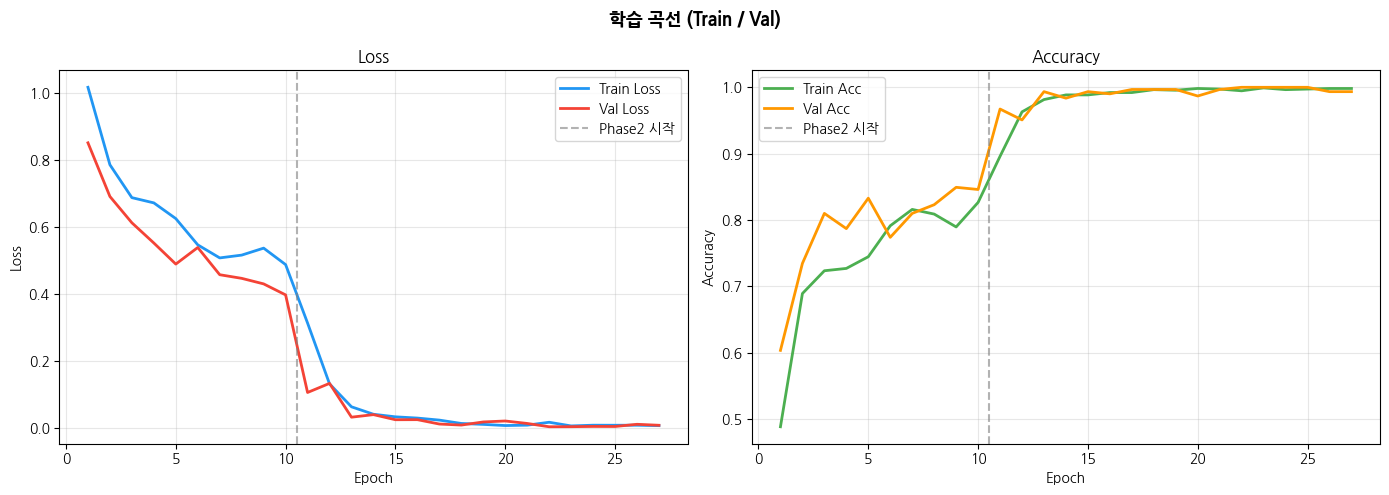

저장: /content/learning_curves.png


In [ ]:
# -- 3-5. 학습 곡선 시각화
hist  = {k: hist1[k] + hist2[k] for k in hist1}
ep    = range(1, len(hist['tr_loss']) + 1)
p1end = len(hist1['tr_loss'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('학습 곡선 (Train / Val)', fontsize=13, fontweight='bold')
ax1.plot(ep, hist['tr_loss'], label='Train Loss', color='#2196F3', lw=2)
ax1.plot(ep, hist['val_loss'], label='Val Loss', color='#F44336', lw=2)
ax1.axvline(p1end + 0.5, color='gray', ls='--', alpha=0.6, label='Phase2 시작')
ax1.set(xlabel='Epoch', ylabel='Loss', title='Loss'); ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(ep, hist['tr_acc'], label='Train Acc', color='#4CAF50', lw=2)
ax2.plot(ep, hist['val_acc'], label='Val Acc', color='#FF9800', lw=2)
ax2.axvline(p1end + 0.5, color='gray', ls='--', alpha=0.6, label='Phase2 시작')
ax2.set(xlabel='Epoch', ylabel='Accuracy', title='Accuracy'); ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/learning_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print("저장: /content/learning_curves.png")

In [ ]:
# -- 3-6. 테스트 세트 최종 평가
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc='테스트 추론'):
        preds = model(imgs.to(DEVICE)).argmax(1).cpu().numpy()
        all_preds.extend(preds); all_labels.extend(labels.numpy())

test_acc = accuracy_score(all_labels, all_preds)
test_f1  = f1_score(all_labels, all_preds, average='macro')

print(f"\n{'='*55}")
print("  테스트 결과")
print(f"{'='*55}")
print(f"  Accuracy : {test_acc:.4f} ({test_acc*100:.1f}%)  [기준: 80%+]")
print(f"  F1-Score : {test_f1:.4f} ({test_f1*100:.1f}%)  [macro]")
print(f"{'='*55}\n")
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

테스트 추론:   0%|          | 0/10 [00:00<?, ?it/s]


  테스트 결과
  Accuracy : 1.0000 (100.0%)  [기준: 80%+]
  F1-Score : 1.0000 (100.0%)  [macro]

              precision    recall  f1-score   support

        HEXA       1.00      1.00      1.00       101
        QUAD       1.00      1.00      1.00       103
        VTOL       1.00      1.00      1.00       103

    accuracy                           1.00       307
   macro avg       1.00      1.00      1.00       307
weighted avg       1.00      1.00      1.00       307



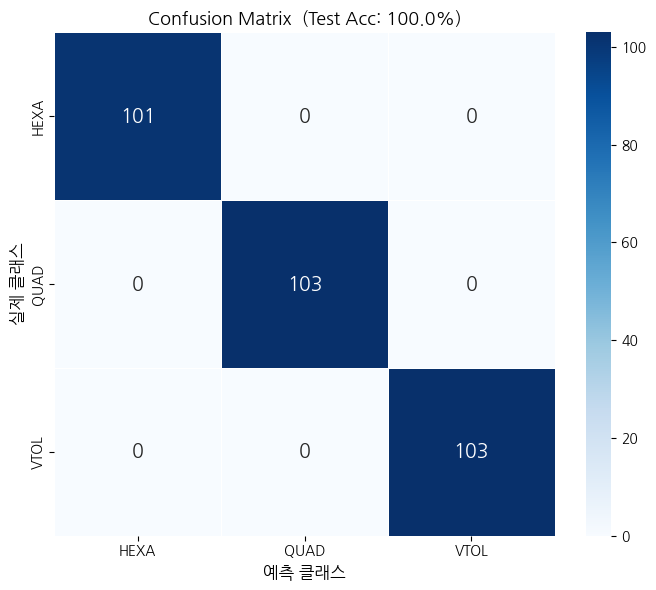

저장: /content/confusion_matrix.png


In [ ]:
# -- 3-7. Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, annot_kws={'size': 14}, ax=ax)
ax.set_xlabel('예측 클래스', fontsize=12)
ax.set_ylabel('실제 클래스', fontsize=12)
ax.set_title(f'Confusion Matrix  (Test Acc: {test_acc:.1%})', fontsize=13)
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()
print("저장: /content/confusion_matrix.png")

## STEP 04 · OpenVINO 최적화

In [ ]:
# -- 4-1. 모델 저장 및 OpenVINO IR 변환 (PyTorch 직접 변환)
# ONNX 경유 없이 ov.convert_model() 로 직접 변환 -> onnxscript 오류 없음

THRESHOLD   = 0.70
MODEL_DIR   = '/content/drone_clf_model'
PT_PATH     = f'{MODEL_DIR}/mobilenetv2_drone.pt'
OV_XML      = f'{MODEL_DIR}/mobilenetv2_drone_ir.xml'
OPENVINO_OK = False

os.makedirs(MODEL_DIR, exist_ok=True)

if test_acc >= THRESHOLD:
    torch.save(model.state_dict(), PT_PATH)
    pt_mb = os.path.getsize(PT_PATH) / 1e6
    print(f"PyTorch 저장: {PT_PATH}  ({pt_mb:.1f} MB)")

    # OpenVINO 직접 변환 (ONNX 불필요)
    model.eval().cpu()
    dummy    = torch.randn(1, 3, IMG_SIZE, IMG_SIZE)
    core     = ov.Core()
    ov_model = ov.convert_model(model, example_input=dummy)
    ov.save_model(ov_model, OV_XML)

    xml_mb = os.path.getsize(OV_XML) / 1e6
    bin_mb = os.path.getsize(OV_XML.replace('.xml', '.bin')) / 1e6
    print(f"OpenVINO IR : {OV_XML}")
    print(f"  .xml: {xml_mb:.2f} MB  |  .bin: {bin_mb:.2f} MB  |  합계: {xml_mb+bin_mb:.2f} MB")
    OPENVINO_OK = True
else:
    print(f"Accuracy {test_acc:.1%} < {THRESHOLD:.0%} -> 모델 저장 건너뜀")

PyTorch 저장: /content/drone_clf_model/mobilenetv2_drone.pt  (9.2 MB)
OpenVINO IR : /content/drone_clf_model/mobilenetv2_drone_ir.xml
  .xml: 0.20 MB  |  .bin: 4.42 MB  |  합계: 4.62 MB


In [ ]:
# -- 4-2. Google Drive에 모델 저장
if OPENVINO_OK:
    DRIVE_MODEL = Path(DRIVE_ROOT) / 'drone_clf_model'
    DRIVE_MODEL.mkdir(parents=True, exist_ok=True)
    for src in [PT_PATH, OV_XML, OV_XML.replace('.xml', '.bin')]:
        if Path(src).exists():
            shutil.copy(src, DRIVE_MODEL)
            print(f"Drive 저장: {Path(src).name}")

Drive 저장: mobilenetv2_drone.pt
Drive 저장: mobilenetv2_drone_ir.xml
Drive 저장: mobilenetv2_drone_ir.bin


In [ ]:
# -- 4-3. Base Model vs OpenVINO IR 추론 성능 비교
if OPENVINO_OK:
    MEAN_NP = np.array([0.485, 0.456, 0.406])
    STD_NP  = np.array([0.229, 0.224, 0.225])

    sample_imgs, sample_gt = [], []
    for imgs, labels in test_loader:
        sample_imgs.append(imgs); sample_gt.extend(labels.numpy())
        if sum(x.size(0) for x in sample_imgs) >= 50: break
    sample_t  = torch.cat(sample_imgs)[:50]
    sample_gt = sample_gt[:50]
    sample_np = sample_t.numpy()

    # Base Model (PyTorch CPU)
    model.eval().cpu()
    t0 = time.perf_counter()
    with torch.no_grad():
        base_preds = model(sample_t).argmax(1).numpy()
    base_ms  = (time.perf_counter() - t0) / len(sample_t) * 1000
    base_acc = accuracy_score(sample_gt, base_preds)
    base_mb  = os.path.getsize(PT_PATH) / 1e6

    # OpenVINO IR (CPU)
    compiled  = core.compile_model(OV_XML, 'CPU')
    out_layer = compiled.output(0)
    t0 = time.perf_counter()
    ov_preds = [np.argmax(compiled([x[np.newaxis]])[out_layer][0]) for x in sample_np]
    ov_ms    = (time.perf_counter() - t0) / len(sample_np) * 1000
    ov_acc   = accuracy_score(sample_gt, ov_preds)
    ov_mb    = (os.path.getsize(OV_XML) + os.path.getsize(OV_XML.replace('.xml','.bin'))) / 1e6

    print(f"\n{'='*56}")
    print(f"  {'항목':<22} {'Base Model':>14} {'OpenVINO IR':>14}")
    print(f"{'='*56}")
    print(f"  {'모델 크기 (MB)':<22} {base_mb:>14.1f} {ov_mb:>14.1f}")
    print(f"  {'추론 시간 (ms/장)':<22} {base_ms:>14.2f} {ov_ms:>14.2f}")
    print(f"  {'FPS':<22} {1000/base_ms:>14.1f} {1000/ov_ms:>14.1f}")
    print(f"  {'Accuracy':<22} {base_acc:>14.4f} {ov_acc:>14.4f}")
    print(f"{'='*56}")
    speedup    = base_ms / ov_ms
    size_ratio = base_mb / ov_mb
    print(f"\n  추론 속도: {speedup:.2f}x 향상")
    print(f"  모델 크기: {size_ratio:.2f}x 감소")


  항목                         Base Model    OpenVINO IR
  모델 크기 (MB)                        9.2            4.6
  추론 시간 (ms/장)                    67.52          10.72
  FPS                              14.8           93.3
  Accuracy                       1.0000         1.0000

  추론 속도: 6.30x 향상
  모델 크기: 1.98x 감소


## STEP 05 · 웹 UI 구현 (Streamlit)

In [ ]:
# -- 5-1. Streamlit 앱 코드 생성
app_code = (
    'import streamlit as st\n'
    'import numpy as np\n'
    'from PIL import Image\n'
    'import openvino as ov\n'
    'import time\n'
    '\n'
    'OV_XML      = "drone_clf_model/mobilenetv2_drone_ir.xml"\n'
    'CLASS_NAMES = ["HEXA", "QUAD", "VTOL"]\n'
    'IMG_SIZE    = 224\n'
    'MEAN = np.array([0.485, 0.456, 0.406])\n'
    'STD  = np.array([0.229, 0.224, 0.225])\n'
    'CLASS_INFO = {"VTOL": "고정익+로터 하이브리드 (흰색, 날개 있음)",'
                 ' "QUAD": "쿼드콥터 (검정, 4개 로터)",'
                 ' "HEXA": "헥사콥터 (회색, 6개 로터)"}\n'
    '\n'
    '@st.cache_resource\n'
    'def load_model():\n'
    '    return ov.Core().compile_model(OV_XML, "CPU")\n'
    '\n'
    'def preprocess(img):\n'
    '    img = img.convert("RGB").resize((IMG_SIZE, IMG_SIZE))\n'
    '    x = (np.array(img, dtype=np.float32) / 255.0 - MEAN) / STD\n'
    '    return x.transpose(2, 0, 1)[np.newaxis]\n'
    '\n'
    'def softmax(x):\n'
    '    e = np.exp(x - x.max()); return e / e.sum()\n'
    '\n'
    'st.set_page_config(page_title="드론 종류 분류기", page_icon="🚁", layout="wide")\n'
    'st.title("🚁 대드론 탐지 - 드론 종류 분류기")\n'
    'st.markdown("**지상 탐지 카메라로 촬영한 드론 이미지**를 업로드하면 기종을 자동 분류합니다.")\n'
    'st.caption("Intel OpenVINO CPU 추론 | Ground-to-Sky 전용 모델")\n'
    'st.divider()\n'
    'col_up, col_res = st.columns([1, 1])\n'
    'with col_up:\n'
    '    uploaded = st.file_uploader("드론 이미지 업로드", type=["jpg","jpeg","png"])\n'
    'if uploaded:\n'
    '    pil_img = Image.open(uploaded)\n'
    '    col_up.image(pil_img, caption="입력 이미지", use_column_width=True)\n'
    '    with st.spinner("OpenVINO 추론 중..."):\n'
    '        compiled  = load_model()\n'
    '        out_layer = compiled.output(0)\n'
    '        t0        = time.perf_counter()\n'
    '        logits    = compiled([preprocess(pil_img)])[out_layer][0]\n'
    '        ms        = (time.perf_counter() - t0) * 1000\n'
    '    probs = softmax(logits)\n'
    '    top_i = int(np.argmax(probs))\n'
    '    top_c = CLASS_NAMES[top_i]\n'
    '    with col_res:\n'
    '        st.markdown("### 분류 결과")\n'
    '        st.success(f"**{top_c}** - {CLASS_INFO[top_c]}")\n'
    '        st.metric("신뢰도", f"{probs[top_i]*100:.1f}%")\n'
    '        st.metric("추론 시간", f"{ms:.1f} ms")\n'
    '        st.divider()\n'
    '        st.markdown("#### 클래스별 확률")\n'
    '        for cls, prob in zip(CLASS_NAMES, probs):\n'
    '            st.progress(float(prob), text=f"{cls}: {prob*100:.1f}%")\n'
)

with open('/content/app.py', 'w', encoding='utf-8') as f:
    f.write(app_code)
print('app.py 저장: /content/app.py')
print()
print('Streamlit 실행 (Colab):')
print('  !pip install pyngrok -q')
print('  from pyngrok import ngrok')
print('  ngrok.set_auth_token("YOUR_TOKEN")')
print('  import subprocess; subprocess.Popen(["streamlit","run","/content/app.py"])')
print('  import time; time.sleep(3)')
print('  print(ngrok.connect(8501).public_url)')